In [1]:
# 与图片分类的区别
# 图片分类: 在一张图片里面有一个主体, 找到主体的类
# 目标检测: 识别一张图片里面所有感兴趣的类别, 并且找到每个物体的位置

# 边缘框
# 一个边缘框可以用4个数字来定义
#   - 左上x, 右上y, 右下x, 右下y
#   - 左上x, 左上y, 宽, 高

# 目标检测数据集
# (图片分类) 放在一个文件夹, 每一个类是一个子文件夹, 对应标号的图片放在这个子文件夹下面
# (目标检测) 因为一个图片有多个类, 标号需要额外存, 常用的是
#   - 每一行表示一个物体, 里面有文件名字, 物体类别, 边缘框
# 常见数据集COCO

# 总结
# 目标检测识别图片里面多个物体的类别和位置
# 位置通常用边缘框表示

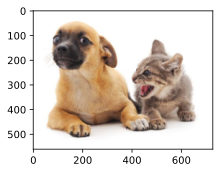

In [3]:
# 边缘框实现
%matplotlib inline
import torch
from d2l import torch as d2l

d2l.set_figsize()
img = d2l.plt.imread('/Users/xinghaozhou/Desktop/DL/d2l-zh/pytorch/img/catdog.jpg')
d2l.plt.imshow(img);

In [15]:
# 定义两种表示之间进行的函数
def box_corner_to_center(boxes):
    # 这里的boxes里面的列分别存了四个需要的信息
    # 从(左上, 右下) 转化到 (中间, 高度, 宽度)
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    w = x2 - x1
    h = y2 - y1
    boxes = torch.stack((cx, cy, w, h), axis=-1)
    return boxes

def box_center_to_corner(boxes):
    # 从(中间, 高度, 宽度) 转化到 (左上, 右下)
    cx, cy, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    boxes = torch.stack((x1, y1, x2, y2), axis=-1)
    return boxes

In [18]:
# 定义图像中狗和猫的边缘框
dog_bbox, cat_bbox = [60.0, 45.0, 378.0, 516.0], [400.0, 112.0, 655.0, 493.0]

boxes = torch.tensor((dog_bbox, cat_bbox))
box_center_to_corner(box_corner_to_center(boxes)) == boxes # 查看转换是否正确

tensor([[ 60.,  45., 378., 516.],
        [400., 112., 655., 493.]])

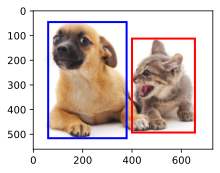

In [19]:
def bbox_to_rect(bbox, color):
    return d2l.plt.Rectangle(xy=(bbox[0],  bbox[1]), 
                             width=bbox[2]-bbox[0], height=bbox[3]-bbox[1],
                             fill = False, edgecolor=color, linewidth=2)

fig=d2l.plt.imshow(img)
fig.axes.add_patch(bbox_to_rect(dog_bbox, 'blue'))
fig.axes.add_patch(bbox_to_rect(cat_bbox, 'red'));

In [20]:
# 目标检测数据集
%matplotlib inline
import os
import pandas as pd
import torch
import torchvision
from d2l import torch as d2l

d2l.DATA_HUB['banana-detection'] = (
    d2l.DATA_URL + 'banana-detection.zip',
    '5de26c8fce5ccdea9f91267273464dc968d20d72')

In [37]:
# 读取香蕉检测数据集
def read_data_bananas(is_train=True):
    # 读取香蕉检测数据集中的图像和标签
    data_dir = d2l.download_extract('banana-detection')
    csv_fname = os.path.join(data_dir,
                             'bananas_train' if is_train else 'bananas_val',
                             'label.csv')
    csv_data = pd.read_csv(csv_fname)
    csv_data = csv_data.set_index('img_name')
    images, targets = [], []
    for img_name, target in csv_data.iterrows():
        images.append(
            torchvision.io.read_image(
                os.path.join(data_dir, # 取出照片
                             'bananas_train' if is_train else 'bananas_val', # 通过img_name中取到的照片标号, 找到照片
                             'images', f'{img_name}')))
        targets.append(list(target)) # 加入检测物体对应的下表
    return images, torch.tensor(targets).unsqueeze(1) / 256 #将结果变为一个nx1的向量, 并归一化

In [38]:
# 创建一个自定义的dataset实例
class BananaDataset(torch.utils.data.Dataset):
    # 一个用于加载香蕉检测数据集的自定义数据集
    def __init__(self, is_train):
        self.features, self.labels = read_data_bananas(is_train)
        print('read ' + str(len(self.features)) + (
            f' training examples' if is_train else f' validation examples'))

    def __getitem__(self, idx):
        return (self.features[idx].float(), self.labels[idx])

    def __len__(self):
        return len(self.features)

In [39]:
# 为训练集和测试集返回两个数据集加载器
def load_data_bananas(batch_size):
    train_iter = torch.utils.data.DataLoader(BananaDataset(is_train=True), batch_size, shuffle=True)
    val_iter = torch.utils.data.DataLoader(BananaDataset(is_train=False), batch_size)
    return train_iter, val_iter

In [40]:
# 读取小批量, 打印其中图像和标签的形状
batch_size, edge_size = 32, 256
train_iter, _ = load_data_bananas(batch_size)
batch = next(iter(train_iter))
batch[0].shape, batch[1].shape

# 这里32是batchsize, 3是rgb的值, 256是宽高
# 同样, 但是这里1是每张图片里最多有几种物体, 5对应的是标号和框的4个坐标

read 1000 training examples
read 100 validation examples


(torch.Size([32, 3, 256, 256]), torch.Size([32, 1, 5]))

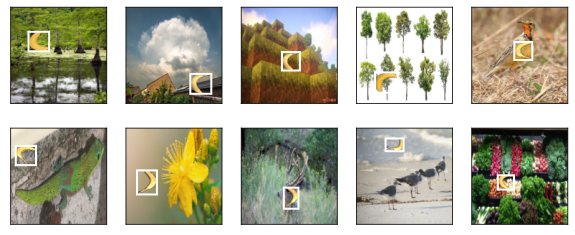

In [41]:
# 示范
imgs = (batch[0][0:10].permute(0, 2, 3, 1)) / 255 #这里permute改变参数维度, dataset里读了5个维度, 画图要求的是3个
axes = d2l.show_images(imgs, 2, 5, scale=2)
for ax, label in zip(axes, batch[1][0:10]): # 拿一个图片和标号, 从batch1的前面10个
    d2l.show_bboxes(ax, [label[0][1:5] * edge_size], colors=['w']) # 这里的label要的是最后4列, 是我们的框的位置, *是把/的b